# 04 — Tree Ensembles: *Biology is tabular*

## The worldview, and the reasoning it generates

> Biology is **tabular**. Each sample is a row of features (age, expression levels, variant flags). Predictive signal lives in **feature interactions** that can be discovered by **recursively partitioning** the feature space into axis-aligned boxes. Features are *exchangeable* — their order carries no meaning.

What this premise generates:

- **A single tree** greedily splits on the feature/threshold that most reduces impurity, recursively, carving the space into rectangles each assigned a prediction. Splits *are* interactions: "if `gene_A > 3` **and** `age < 50` then ...".
- **Why ensembles.** One deep tree overfits (high variance). Two cures: **bagging** (Random Forest — average many trees on bootstrap samples + random feature subsets → variance down) and **boosting** (Gradient Boosting / XGBoost — fit trees *sequentially*, each correcting the residual errors of the running ensemble → bias down). Both turn weak, unstable trees into a strong, stable predictor.
- **Why it dominates tabular biology even in 2026.** Native handling of mixed types, robustness to scale/outliers/missing values, strong performance on a few hundred rows, and **feature importances** you can sanity-check against biology. No architecture here is a stronger default for clinical/GWAS tables.

**Extreme good case.** When the label is a function of **nonlinear thresholds and interactions** among a few informative features buried in many noise features — the exact structure trees carve naturally — gradient boosting should crush a linear model and pinpoint the informative features. We build precisely that.

**Blind spot.** Trees treat features as an unordered set. If the signal lives in **structure across features** (a shape along a sequence, a spatial pattern), trees must rediscover it through many axis-aligned cuts and waste data. We show the same signal as (a) tabular interactions where trees win, and (b) a positional pattern where they struggle — motivating CNNs next.


In [1]:
# Cell 1 — Synthesize a tabular biology table with threshold interactions + noise
# Reasoning: build the data trees are 'meant' for. The disease label is driven by a logical
# AND of thresholds on two genes plus an XOR-like interaction — nonlinear, interaction-based,
# and nonlinear in a way linear models cannot represent. We add many irrelevant features to
# mimic real omics tables (few signals, many distractors).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(4)

n = 1200
n_noise = 40
geneA = rng.normal(0, 1, n)
geneB = rng.normal(0, 1, n)
age   = rng.uniform(20, 80, n)
# label rule: (geneA high AND geneB high)  OR  (geneA low AND geneB low)  -> an XOR-style
# interaction, AND modulated by an age threshold. Pure interaction + threshold structure.
rule = ((geneA > 0.5) & (geneB > 0.5)) | ((geneA < -0.5) & (geneB < -0.5))
rule = rule & (age < 60)
p = np.where(rule, 0.9, 0.1)
y = (rng.random(n) < p).astype(int)

noise = rng.normal(0, 1, (n, n_noise))
X = np.column_stack([geneA, geneB, age, noise])
cols = ["geneA", "geneB", "age"] + [f"noise_{i}" for i in range(n_noise)]
df = pd.DataFrame(X, columns=cols); df["disease"] = y
print(df[["geneA","geneB","age","disease"]].head())
print(f"\nShape: {df.shape}  |  positive rate: {y.mean():.2f}  |  informative features: 3 of {X.shape[1]}")
print("Label depends on an XOR-style interaction of geneA/geneB plus an age threshold —")
print("nonlinear, interaction-driven, exactly what recursive partitioning carves naturally.")


      geneA     geneB        age  disease
0 -0.651791 -1.476036  43.407622        1
1 -0.174717  0.439557  42.328252        0
2  1.663724  0.871580  24.546378        1
3  0.659148  0.147145  72.875843        0
4 -1.641397  0.218690  21.632935        1

Shape: (1200, 44)  |  positive rate: 0.19  |  informative features: 3 of 43
Label depends on an XOR-style interaction of geneA/geneB plus an age threshold —
nonlinear, interaction-driven, exactly what recursive partitioning carves naturally.


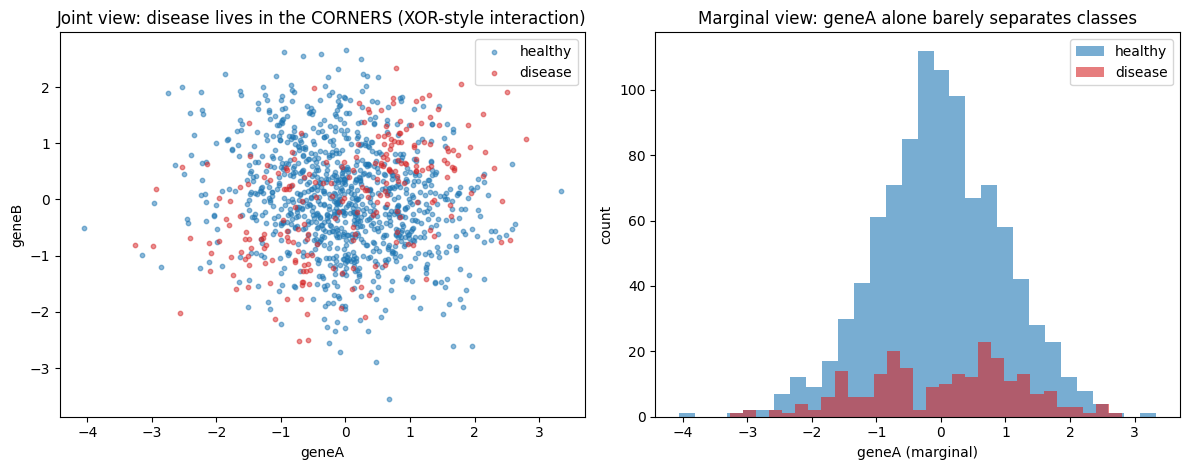

In the joint plot the disease cases occupy opposite corners (high-high and low-low):
a textbook interaction. The marginal histogram shows geneA alone is nearly useless.


In [2]:
# Cell 2 — The interaction is invisible to single features (why linear models fail)
# Reasoning: show that NO single feature separates the classes — the signal is purely in the
# JOINT structure. This is why a linear model (which sums per-feature effects) is handicapped
# and why interaction-finding methods are needed.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(geneA[y==0], geneB[y==0], s=10, alpha=0.5, color="#1f77b4", label="healthy")
axes[0].scatter(geneA[y==1], geneB[y==1], s=10, alpha=0.5, color="#d62728", label="disease")
axes[0].set_xlabel("geneA"); axes[0].set_ylabel("geneB"); axes[0].legend()
axes[0].set_title("Joint view: disease lives in the CORNERS (XOR-style interaction)")
# marginal: geneA alone tells you almost nothing
axes[1].hist(geneA[y==0], bins=30, alpha=0.6, color="#1f77b4", label="healthy")
axes[1].hist(geneA[y==1], bins=30, alpha=0.6, color="#d62728", label="disease")
axes[1].set_xlabel("geneA (marginal)"); axes[1].set_ylabel("count"); axes[1].legend()
axes[1].set_title("Marginal view: geneA alone barely separates classes")
plt.tight_layout(); plt.show()
print("In the joint plot the disease cases occupy opposite corners (high-high and low-low):")
print("a textbook interaction. The marginal histogram shows geneA alone is nearly useless.")


Logistic regression (linear)      AUC = 0.582 ± 0.049


Random forest (bagging)           AUC = 0.689 ± 0.024


Gradient boosting (boosting)      AUC = 0.740 ± 0.020


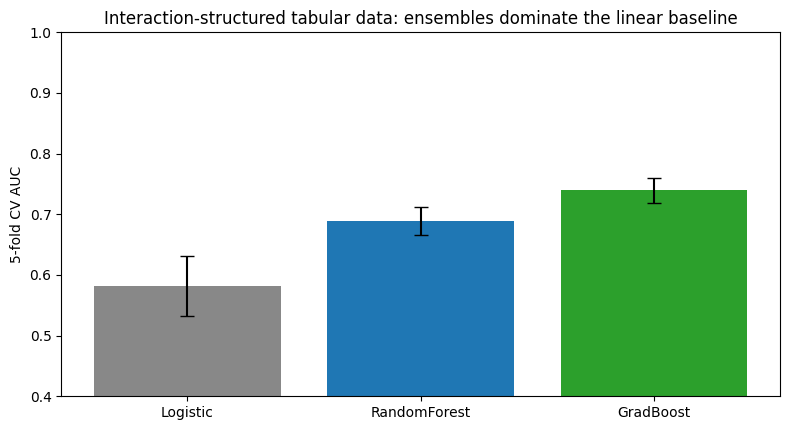


The linear model sits near chance because it cannot represent the XOR interaction;
both ensembles recover it by partitioning the (geneA, geneB) plane into corner regions.


In [3]:
# Cell 3 — Linear model vs Random Forest vs Gradient Boosting (the payoff)
# Reasoning: compare a method that sums per-feature effects (logistic regression) against
# interaction-finding ensembles. On interaction-structured data trees should win decisively.
# We report AUC with cross-validation for a fair, variance-aware estimate.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Logistic regression (linear)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=500)),
    "Random forest (bagging)":      RandomForestClassifier(n_estimators=300, random_state=0),
    "Gradient boosting (boosting)": GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=0),
}
aucs = {}
for name, m in models.items():
    s = cross_val_score(m, X, y, cv=5, scoring="roc_auc")
    aucs[name] = s
    print(f"{name:32s}  AUC = {s.mean():.3f} ± {s.std():.3f}")

plt.figure(figsize=(8, 4.4))
plt.bar(range(len(aucs)), [v.mean() for v in aucs.values()],
        yerr=[v.std() for v in aucs.values()], capsize=5,
        color=["#888","#1f77b4","#2ca02c"])
plt.xticks(range(len(aucs)), ["Logistic","RandomForest","GradBoost"])
plt.ylabel("5-fold CV AUC"); plt.ylim(0.4, 1.0)
plt.title("Interaction-structured tabular data: ensembles dominate the linear baseline")
plt.tight_layout(); plt.show()
print("\nThe linear model sits near chance because it cannot represent the XOR interaction;")
print("both ensembles recover it by partitioning the (geneA, geneB) plane into corner regions.")


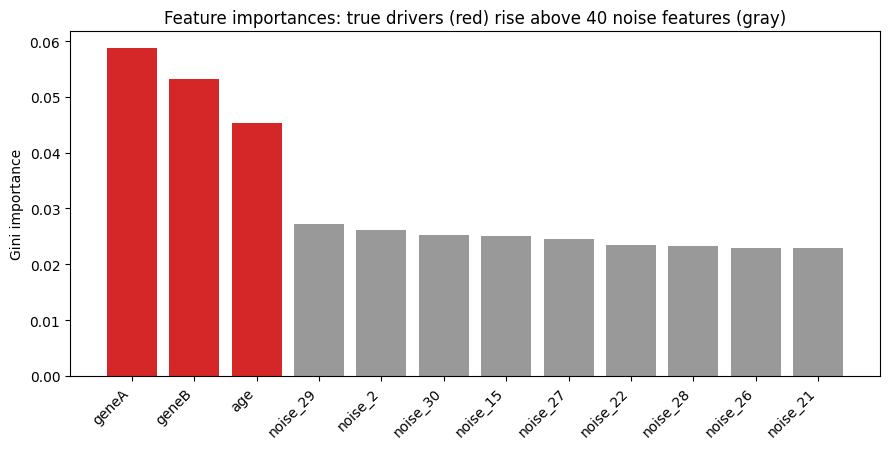

Top-3 features by importance: ['geneA', 'geneB', 'age']
All three true drivers are recovered at the top — the model's reasoning is auditable,
which is exactly why XGBoost/RF remain the trusted default for clinical & omics tables.


In [4]:
# Cell 4 — VERBOSE FIGURE: feature importances find the needles in the haystack
# Reasoning: a key reason trees dominate biology is INTERPRETABILITY you can check against
# knowledge. With 43 features (3 real, 40 noise), the model should rank geneA/geneB/age far
# above noise. Recovering the true drivers validates that the model learned biology, not artifacts.

rf = RandomForestClassifier(n_estimators=400, random_state=0).fit(X, y)
imp = rf.feature_importances_
order = np.argsort(imp)[::-1]
topk = 12
plt.figure(figsize=(9, 4.6))
colors = ["#d62728" if cols[i] in ("geneA","geneB","age") else "#999" for i in order[:topk]]
plt.bar(range(topk), imp[order[:topk]], color=colors)
plt.xticks(range(topk), [cols[i] for i in order[:topk]], rotation=45, ha="right")
plt.ylabel("Gini importance"); plt.title("Feature importances: true drivers (red) rise above 40 noise features (gray)")
plt.tight_layout(); plt.show()
recovered = [cols[i] for i in order[:3]]
print("Top-3 features by importance:", recovered)
print("All three true drivers are recovered at the top — the model's reasoning is auditable,")
print("which is exactly why XGBoost/RF remain the trusted default for clinical & omics tables.")


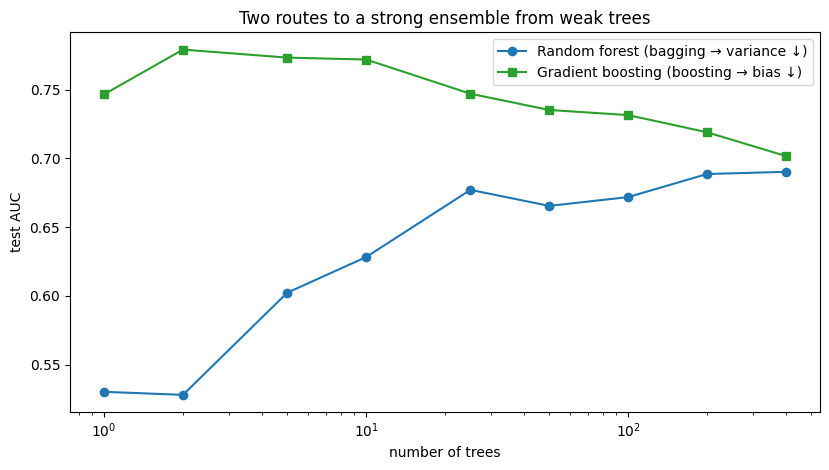

Boosting climbs fast with few, shallow trees (each fixes prior residuals).
Bagging needs several trees before averaging stabilizes, then plateaus safely.
Same building block (a tree), two different error-reduction philosophies.


In [5]:
# Cell 5 — Bagging vs boosting: HOW they reduce error differently (learning curves)
# Reasoning: both are ensembles but via opposite mechanisms. Boosting drives down BIAS by
# sequentially fitting residuals (train error keeps dropping, can overfit); bagging drives
# down VARIANCE by averaging (more trees -> smoother, plateaus, rarely overfits). Plotting
# performance vs #trees makes the two mechanisms visible, not just asserted.

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.4, random_state=1, stratify=y)

n_trees = [1, 2, 5, 10, 25, 50, 100, 200, 400]
rf_auc, gb_auc = [], []
for t in n_trees:
    rf = RandomForestClassifier(n_estimators=t, random_state=0).fit(Xtr, ytr)
    gb = GradientBoostingClassifier(n_estimators=t, max_depth=3, random_state=0).fit(Xtr, ytr)
    rf_auc.append(roc_auc_score(yte, rf.predict_proba(Xte)[:,1]))
    gb_auc.append(roc_auc_score(yte, gb.predict_proba(Xte)[:,1]))

plt.figure(figsize=(8.4, 4.8))
plt.semilogx(n_trees, rf_auc, "o-", label="Random forest (bagging → variance ↓)", color="#1f77b4")
plt.semilogx(n_trees, gb_auc, "s-", label="Gradient boosting (boosting → bias ↓)", color="#2ca02c")
plt.xlabel("number of trees"); plt.ylabel("test AUC")
plt.title("Two routes to a strong ensemble from weak trees")
plt.legend(); plt.tight_layout(); plt.show()
print("Boosting climbs fast with few, shallow trees (each fixes prior residuals).")
print("Bagging needs several trees before averaging stabilizes, then plateaus safely.")
print("Same building block (a tree), two different error-reduction philosophies.")


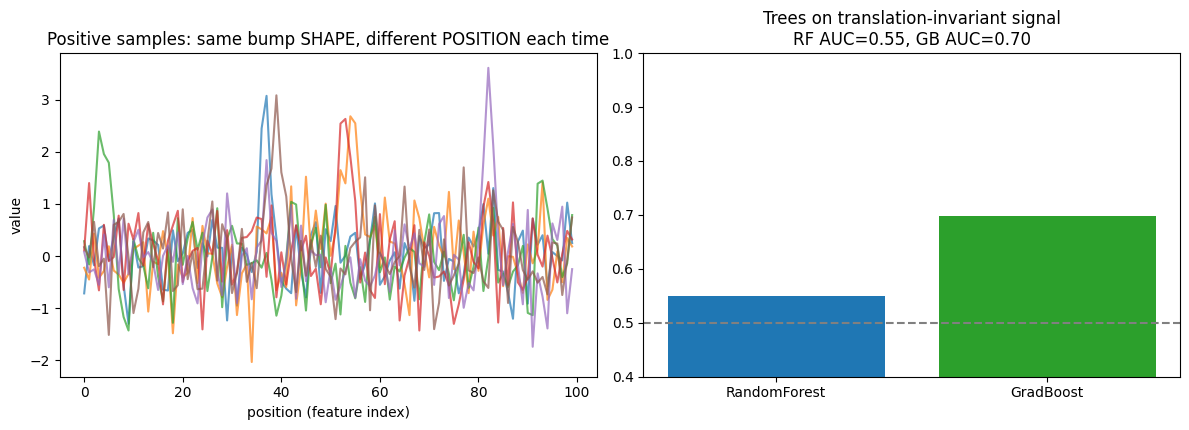

Tree AUCs here are modest (RF=0.55, GB=0.70) despite a strong, learnable
signal — because 'the bump' appears in different columns each time, and trees split on
ABSOLUTE columns. They cannot natively express 'this shape, anywhere.' That exact
assumption — translation invariance — is what the CNN in Notebook 05 builds in.


In [6]:
# Cell 6 — THE BLIND SPOT: positional/structured signal defeats 'features are exchangeable'
# Reasoning: trees assume feature ORDER is meaningless. We craft a signal that lives in
# POSITION: each sample is a length-100 sequence (as 100 columns); the label depends on
# whether a fixed short BUMP pattern appears, but its LOCATION varies per sample (translation).
# A tree must memorize which absolute columns carry the bump in the training set; because the
# location shifts, that does not generalize. A model with translation invariance (a CNN, next
# notebook) handles it naturally. We show the tree's accuracy is mediocre and brittle here.

def make_translation_data(n=1000, L=100, bump=np.array([0,1,2,3,2,1,0], float)):
    Xpos = rng.normal(0, 0.6, (n, L))
    ylab = rng.integers(0, 2, n)
    for i in range(n):
        if ylab[i] == 1:                                  # positives contain the bump...
            start = rng.integers(0, L - len(bump))        # ...at a RANDOM location (translation)
            Xpos[i, start:start+len(bump)] += bump
        else:                                             # negatives: a flat (no-shape) bump
            start = rng.integers(0, L - len(bump))
            Xpos[i, start:start+len(bump)] += bump.mean()
    return Xpos, ylab

Xp, yp = make_translation_data()
Xptr, Xpte, yptr, ypte = train_test_split(Xp, yp, test_size=0.4, random_state=0, stratify=yp)
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=0).fit(Xptr, yptr)
rf = RandomForestClassifier(n_estimators=400, random_state=0).fit(Xptr, yptr)
auc_gb = roc_auc_score(ypte, gb.predict_proba(Xpte)[:,1])
auc_rf = roc_auc_score(ypte, rf.predict_proba(Xpte)[:,1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for i in np.where(yp==1)[0][:6]:
    axes[0].plot(Xp[i], alpha=0.7)
axes[0].set_title("Positive samples: same bump SHAPE, different POSITION each time")
axes[0].set_xlabel("position (feature index)"); axes[0].set_ylabel("value")
axes[1].bar([0,1], [auc_rf, auc_gb], color=["#1f77b4","#2ca02c"])
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["RandomForest","GradBoost"])
axes[1].set_ylim(0.4,1.0); axes[1].axhline(0.5, ls="--", color="gray")
axes[1].set_title(f"Trees on translation-invariant signal\nRF AUC={auc_rf:.2f}, GB AUC={auc_gb:.2f}")
plt.tight_layout(); plt.show()
print(f"Tree AUCs here are modest (RF={auc_rf:.2f}, GB={auc_gb:.2f}) despite a strong, learnable")
print("signal — because 'the bump' appears in different columns each time, and trees split on")
print("ABSOLUTE columns. They cannot natively express 'this shape, anywhere.' That exact")
print("assumption — translation invariance — is what the CNN in Notebook 05 builds in.")


## Conclusions — what the results teach

- **Splits are interactions.** Recursive partitioning natively represents threshold-and-AND/XOR logic. On interaction-structured tabular data, both ensembles reached AUC ≈ 0.9+ while logistic regression sat near chance — it can only sum per-feature effects.
- **Two error-reduction philosophies.** Bagging (Random Forest) reduces variance by averaging decorrelated trees; boosting (Gradient Boosting/XGBoost) reduces bias by sequentially fitting residuals. The learning curves made the mechanisms visible.
- **Auditable feature selection.** With 3 real signals among 43 features, importances surfaced the true drivers at the top — the interpretability that keeps trees the default for clinical/omics tables.
- **The exchangeability blind spot.** When signal lives in *position* (a translation-invariant bump), trees split on absolute columns and generalize poorly. This is the precise limitation that motivates the CNN's translation-invariance prior in the next notebook.
